In [ ]:
from pathlib import Path
import sys

PROJECT_ROOT = next(
    (path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
     if (path / "scripts").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not find the repository scripts directory.")

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

V3LE_ROOT = Path("/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3LE_paper")
V3LE_FIG_ROOT = V3LE_ROOT / "figures"
V3LE_DIAG_DIR = V3LE_ROOT / "diag_data"
FIG_DIR_ROOT = V3LE_FIG_ROOT / "budget"

In [1]:
from __future__ import annotations

import os
import glob
import re
import json
import time
import datetime
from typing import Dict, Optional, Tuple, List
import pandas as pd 
import xarray as xr

import unicodedata
import pprint, shutil

try:
    # xCDAT for CF bounds utilities and lon handling
    from xcdat import open_dataset as xcdat_open
    _HAVE_XCDAT = True
except Exception:
    xcdat_open = xr.open_dataset
    _HAVE_XCDAT = False

try:
    import xskillscore as xs
    _HAVE_XS = True
except Exception:
    _HAVE_XS = False

# optional: MetPy smoothing (safe fallback if not installed)
try:
    from metpy.calc import smooth_n_point as _smooth_n_point
    _HAS_METPY = True
except Exception:
    _HAS_METPY = False
    def _smooth_n_point(arr, n=9, passes=2):
        return arr  # no-op fallback
    
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as matcolors
import matplotlib.path as matpath
import matplotlib.ticker as mticker
import matplotlib.contour as mcontour
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from collections.abc import Mapping

from matplotlib.offsetbox import AnchoredText
from matplotlib.colors import BoundaryNorm

# Local imports
from exp_info import REGION_CATALOG, VARIABLE_CATALOG, Budget_CATALOG


In [15]:
# exp_data_reader_raw.py

import os, re, unicodedata
from typing import Optional, Dict, Tuple, Iterable, List, Union
import numpy as np
import xarray as xr

class ExpDataReader:
    """
    TS-focused reader for pre-averaged regional annual-mean **raw** time series.

    - Set regnam=None to run in TS-only mode (no lat/lon/land-mask logic).
    - Expects files like: {prefix}.enNN.{tail}.{period}.nc
      e.g., v3.LR.historical.en01.area_mean_ts.185001-202412.nc
    - No anomaly handling here; this class is raw-only.
    """

    def __init__(
        self,
        data_dir: str,
        regnam: Optional[str],  # None => TS-only mode
        dtype: str,
        *,
        region_catalog: Optional[Dict[str, Tuple[Tuple[float, float], Tuple[float, float]]]] = None,
        land_mask_ref: str = "MODIS.observation",  # API compatibility; unused in TS mode
        land_mask_var: str = "TS",                 # API compatibility; unused in TS mode
        anom_type: Optional[str] = None,           # kept for API compatibility; unused
        debug_key: Optional[str] = None,
        verbose: bool = False,
    ):
        self.data_dir = os.path.abspath(data_dir)
        self.regnam   = regnam
        self.dtype    = dtype
        try:
            self.region_catalog = dict(region_catalog) if region_catalog is not None else dict(REGION_CATALOG)  # type: ignore[name-defined]
        except NameError:
            self.region_catalog = dict(region_catalog) if region_catalog is not None else {}
        self.land_mask_var = land_mask_var
        self.land_mask_ref = land_mask_ref
        self.debug_key     = debug_key
        self.verbose       = verbose
        self.anom_type     = anom_type  # unused; retained so callers don't break
        self.exp_dict: Dict[str, xr.Dataset] = {}
        self.land_mask: Optional[xr.DataArray] = None  # compatibility

    # =======================
    # Ensemble TS I/O & utils
    # =======================
    def _normalize_period_str(self, s: str) -> str:
        """Replace Unicode dashes with '-' and strip."""
        _DASHES = {"\u2010": "-", "\u2011": "-", "\u2012": "-",
                   "\u2013": "-", "\u2014": "-", "\u2212": "-"}
        s = unicodedata.normalize("NFKC", s)
        return s.translate(str.maketrans(_DASHES)).strip()

    @staticmethod
    def _fmt_ens_id(k: Union[int, str]) -> str:
        """Return zero-padded 2-digit ensemble id as string ('01', '02', ...)."""
        if isinstance(k, int):
            if k < 0: raise ValueError(f"Ensemble id must be positive; got {k}.")
            return f"{k:02d}"
        m = re.search(r"(\d+)$", str(k))
        if not m: raise ValueError(f"Cannot parse ensemble id from: {k!r}")
        v = int(m.group(1))
        if v < 0: raise ValueError(f"Ensemble id must be positive; got {v} (from {k!r}).")
        return f"{v:02d}"

    def _default_ens_ids(self, n: int) -> List[str]:
        return [self._fmt_ens_id(i) for i in range(1, n + 1)]

    @staticmethod
    def _assert_annual_timeindex(ds: xr.Dataset, fname: str):
        """Verify strictly annual, contiguous by 1 year."""
        if "time" in ds.coords:
            try:
                years = np.asarray(ds.indexes["time"].year)
            except Exception:
                years = np.asarray(xr.decode_cf(ds).indexes["time"].year)  # type: ignore[attr-defined]
        elif "year" in ds.coords:
            years = np.asarray(ds["year"].values)
        else:
            raise ValueError(f"[ens] No 'time' or 'year' coordinate in {fname}.")
        if len(years) <= 1: return
        diffs = np.diff(years)
        if not np.all(diffs == 1):
            raise ValueError(f"[ens] Non-annual or non-contiguous years in {fname}. diffs={np.unique(diffs)}")

    @staticmethod
    def _ensure_time_coord(ds: xr.Dataset, *, fname: str) -> xr.Dataset:
        """Normalize 'year' -> datetime64[ns] 'time' at Jan-01 if 'time' is missing."""
        if "time" in ds.coords: return ds
        if "year" not in ds.coords:
            raise ValueError(f"[ens] Neither 'time' nor 'year' found in {fname}.")
        years = np.asarray(ds["year"].values, dtype="int64")
        times = np.array([np.datetime64(f"{int(y):04d}-01-01", "ns") for y in years])
        if "year" in ds.dims:
            ds = ds.rename({"year": "time"}).assign_coords(time=("time", times))
        else:
            ds = ds.assign_coords(time=("time", times))
        return ds

    # ---------- Raw budget variable checks ----------
    @staticmethod
    def _validate_budget_raw_vars(ds: xr.Dataset, *, require_cre: bool = False):
        """
        Ensure variables needed by the raw TS budget exist.

        Required:
          TS, FSDSC, SHFLX, LHFLX, and (FLDSC or FLDS),
          and either ALBEDOC_SRF or (FSNSC & FSDSC).
        Optional (if require_cre=True):
          SWCF_SRF and LWCF_SRF.
        """
        missing: List[str] = []
        for v in ["TS", "FSDSC", "SHFLX", "LHFLX"]:
            if v not in ds: missing.append(v)
        if ("FLDSC" not in ds) and ("FLDS" not in ds):
            missing.append("FLDSC|FLDS")
        if ("ALBEDOC_SRF" not in ds) and not (("FSNSC" in ds) and ("FSDSC" in ds)):
            missing.append("ALBEDOC_SRF | (FSNSC+FSDSC)")
        if require_cre and not (("SWCF_SRF" in ds) and ("LWCF_SRF" in ds)):
            missing.append("SWCF_SRF+LWCF_SRF")
        if missing:
            raise KeyError(f"Missing required raw variables for TS budget: {', '.join(missing)}")

    def read_ensemble_ts(
        self,
        *,
        prefix: str = "v3.LR.historical",
        ens_ids: Optional[Iterable[Union[int, str]]] = None,
        period: str = "185001-202412",
        tail: str = "area_mean_ts",
        join: str = "exact",      # 'exact' | 'inner' | 'outer'
        decode_times: bool = True,
        chunks: Optional[Dict[str, int]] = None,
        drop_non_shared_vars: bool = False,
        validate_annual: bool = True,
        verbose: Optional[bool] = None,
        l_diag_check: bool = True,
        require_budget_vars: bool = False,
        require_cre: bool = False,
    ) -> xr.Dataset:
        """
        Load RAW ensemble files like: {prefix}.enNN.{tail}.{period}.nc
        Returns a Dataset concatenated along new 'ens' dimension.
        """
        vflag = self.verbose if verbose is None else verbose
        period = self._normalize_period_str(period)

        # Infer ensemble ids
        if ens_ids is None:
            pattern = re.compile(
                rf"^{re.escape(prefix)}\.en(\d+)\.{re.escape(tail)}\.{re.escape(period)}\.nc$"
            )
            found: List[int] = []
            for fn in os.listdir(self.data_dir):
                m = pattern.match(fn)
                if m: found.append(int(m.group(1)))
            if not found:
                raise FileNotFoundError(
                    f"No ensemble files found in {self.data_dir} matching "
                    f"'{prefix}.enNN.{tail}.{period}.nc'"
                )
            ens_ids = [self._fmt_ens_id(i) for i in sorted(found)]
        else:
            ens_ids = [self._fmt_ens_id(k) for k in ens_ids]

        members: List[xr.Dataset] = []
        vars_intersection: Optional[set] = None
        time_values_ref = None

        for eid in ens_ids:
            fn = f"{prefix}.en{eid}.{tail}.{period}.nc"
            fpath = os.path.join(self.data_dir, fn)
            if not os.path.exists(fpath):
                raise FileNotFoundError(f"Missing ensemble member file: {fpath}")
            if vflag: print(f"[ens] loading {fpath}")

            ds = xr.open_dataset(fpath, decode_times=decode_times, chunks=chunks)

            if validate_annual: self._assert_annual_timeindex(ds, fn)
            ds = self._ensure_time_coord(ds, fname=fn)

            data_vars = set(ds.data_vars)
            vars_intersection = data_vars if vars_intersection is None else (vars_intersection & data_vars)

            if time_values_ref is None:
                time_values_ref = ds["time"].values
            else:
                if join == "exact" and not np.array_equal(ds["time"].values, time_values_ref):
                    raise ValueError(f"[ens] time mismatch in {fn}. Use join='inner' or 'outer'.")

            ds = ds.expand_dims(ens=[int(eid)])
            if vflag: print(f"  [ok] member {eid} sizes:", dict(ds.sizes))
            members.append(ds)

        # Align by time (never on 'ens')
        if join in ("inner", "outer"):
            try:
                members = list(xr.align(*members, join=join, exclude=["ens"]))
            except TypeError:
                if join == "inner":
                    common_time = members[0]["time"].to_index()
                    for m in members[1:]:
                        common_time = common_time.intersection(m["time"].to_index())
                    members = [m.reindex(time=common_time) for m in members]
                else:
                    union_time = members[0]["time"].to_index()
                    for m in members[1:]:
                        union_time = union_time.union(m["time"].to_index())
                    members = [m.reindex(time=union_time) for m in members]
        elif join != "exact":
            raise ValueError("join must be one of 'exact' | 'inner' | 'outer'")

        if drop_non_shared_vars and vars_intersection is not None:
            keep = sorted(vars_intersection)
            members = [m[keep] for m in members]

        ens_ds = xr.concat(members, dim="ens").sortby("ens")

        # Optional: validate presence of budget vars for the RAW TS budget
        if require_budget_vars:
            self._validate_budget_raw_vars(ens_ds, require_cre=require_cre)

        # Cache
        self.exp_dict["ENSEMBLE_TS"] = ens_ds

        if l_diag_check:
            try:
                gmean = {v: float(ens_ds[v].mean(("ens", "time"), skipna=True).values)
                         for v in list(ens_ds.data_vars)[:10]}
                print("[diag] global mean over (ens,time) of first 10 RAW vars:")
                for k, val in gmean.items():
                    print(f"        {k:>25s}: {val:+.3e}")
            except Exception as e:
                print(f"[diag] skipped global-mean check: {e}")

        return ens_ds

    # ---------- simple ensemble summaries ----------
    @staticmethod
    def ensemble_stats(ds: xr.Dataset, vars: Optional[Iterable[str]] = None) -> xr.Dataset:
        """Mean & std across 'ens' → returns variables named VAR_mean, VAR_std."""
        if "ens" not in ds.dims:
            raise ValueError("Dataset has no 'ens' dimension.")
        var_list = list(vars) if vars is not None else list(ds.data_vars)
        out: Dict[str, xr.DataArray] = {}
        n_ens = int(ds.sizes.get("ens", 0))
        ddof = 1 if n_ens > 1 else 0
        for v in var_list:
            if v not in ds: continue
            out[f"{v}_mean"] = ds[v].mean("ens", skipna=True)
            out[f"{v}_std"]  = ds[v].std("ens", skipna=True, ddof=ddof)
        return xr.Dataset(out)

    @staticmethod
    def ensemble_quantiles(
        ds: xr.Dataset,
        q: Iterable[float] = (5, 50, 95),
        vars: Optional[Iterable[str]] = None,
    ) -> xr.Dataset:
        """Quantiles across 'ens' for given variables."""
        if "ens" not in ds.dims:
            raise ValueError("Dataset has no 'ens' dimension.")
        qs = np.array(list(q), dtype=float) / 100.0
        q_labels = np.array(np.round(np.array(list(q), dtype=float)).astype(int))
        var_list = list(vars) if vars is not None else list(ds.data_vars)
        q_das: List[xr.Dataset] = []
        for v in var_list:
            if v not in ds: continue
            qv = ds[v].quantile(q=qs, dim="ens", skipna=True)
            qv = qv.assign_coords(quantile=("quantile", q_labels))
            q_das.append(qv.to_dataset(name=v))
        return xr.merge(q_das) if q_das else xr.Dataset()


In [20]:
class EnsembleTSBudgetRaw:
    """
    Annual-mean, raw (all-sky/clear-sky) TS budget with ensemble dimension.

    Physics (per member, per year y)
    --------------------------------
    dTs/dt |_y = (1/Ceff) * [ SWclr_y + LWclr_y - eps*sigma*Ts_y^4 + CRE_sfc_y - SH_y - LH_y ]

      SWclr_y  = (1 - alpha_y) * FSDSC_y
      LWclr_y  = FLDSC_y   (or FLDS_y if only all-sky downward LW is provided)
      CRE_sfc  = SWCF_SRF_y + LWCF_SRF_y      # if available; else omitted
      alpha_y  = ALBEDOC_SRF_y  or  1 - FSNSC_y/FSDSC_y

    Inputs (dims: 'ens','time')
    ---------------------------
    raw must contain:
      TS            : K or °C
      FSDSC         : Clear-sky SW down at surface (W m^-2)
      (ALBEDOC_SRF) or (FSNSC & FSDSC)  -> to form alpha
      (FLDSC or FLDS): Clear-sky (preferred) or all-sky LW down (W m^-2)
      SHFLX, LHFLX  : Sensible & latent heat upward (W m^-2, upward positive)
      (SWCF_SRF & LWCF_SRF) : surface CRE components (W m^-2), optional

    Outputs (units K/yr, left-indexed y→y+1)
    ----------------------------------------
      TSDT_ALL, TSDT_SWclr, TSDT_LWclr, TSDT_Planck,
      TSDT_CRE (if available), TSDT_SH, TSDT_LH,
      TSDT_Sum, TSDT_RESID

    Methods
    -------
    - estimate_ceff()      -> float (J m^-2 K^-1)
    - compute(ceff=...)    -> xr.Dataset with terms above
    - compute_stats(...)   -> tidy DF of ensemble mean & bands
    - plot_terms(...)      -> one figure per term
    """

    def __init__(
        self,
        raw: xr.Dataset,
        *,
        eps: float = 1.0,
        name: Optional[str] = None,
        include_residual: bool = True,
        sum_requested: bool = True,
    ):
        self.raw = raw.copy()
        self.eps = float(eps)
        self.name = name or "experiment"
        self.include_residual = bool(include_residual)
        self.sum_requested = bool(sum_requested)
        self._validate_dims()

    # ----------------- internals -----------------

    def _validate_dims(self):
        if not (("ens" in self.raw.dims) and ("time" in self.raw.dims)):
            raise ValueError("raw must have dims ('ens','time').")

    def _alpha(self) -> xr.DataArray:
        if "ALBEDOC_SRF" in self.raw:
            return self.raw["ALBEDOC_SRF"].astype("float64").clip(0.0, 1.0)
        if ("FSNSC" in self.raw) and ("FSDSC" in self.raw):
            fsnsc = self.raw["FSNSC"].astype("float64")
            fsdsc = self.raw["FSDSC"].astype("float64")
            with np.errstate(divide="ignore", invalid="ignore"):
                ratio = xr.where(fsdsc == 0.0, np.nan, fsnsc / fsdsc)
            return (1.0 - ratio).clip(0.0, 1.0)
        raise KeyError("Need ALBEDOC_SRF or (FSNSC & FSDSC) in 'raw' to form albedo.")

    def _lw_down_clr(self) -> xr.DataArray:
        if "FLDSC" in self.raw:
            return self.raw["FLDSC"].astype("float64")
        if "FLDS" in self.raw:
            return self.raw["FLDS"].astype("float64")
        raise KeyError("Need FLDSC or FLDS in 'raw' for LW down.")

    # ----------------- estimators -----------------
    def _ensure_kelvin(self, da: xr.DataArray) -> xr.DataArray:
        try:
            mx = float(np.nanmax(da.values))
        except Exception:
            mx = np.nan
        return da + 273.15 if (np.isfinite(mx) and mx < 150.0) else da


    def estimate_ceff(self) -> float:
        """
        Estimate C_eff from the raw annual-mean budget (ensemble means for stability):
          ΔT_y = (1/Ceff) * RHS_y,  slope through origin -> 1/Ceff
        RHS_y = SWclr_y + LWclr_y + CRE_y - SH_y - LH_y - eps*sigma*Ts_y^4
        """
        ts = self._ensure_kelvin(self.raw["TS"].astype("float64")).mean("ens")       # (time,)
        dT = ts.diff("time")

        alpha = self._alpha().mean("ens")
        fsdsc = self.raw["FSDSC"].astype("float64").mean("ens")
        swclr = (1.0 - alpha) * fsdsc

        lwclr = self._lw_down_clr().mean("ens")

        cre = 0.0 * ts
        if "SWCF_SRF" in self.raw and "LWCF_SRF" in self.raw:
            cre = (self.raw["SWCF_SRF"] + self.raw["LWCF_SRF"]).astype("float64").mean("ens")

        sh = self.raw["SHFLX"].astype("float64").mean("ens")
        lh = self.raw["LHFLX"].astype("float64").mean("ens")
        
        SIGMA = 5.670374419e-8  # W m^-2 K^-4
        planck = self.eps * SIGMA * (ts ** 4)

        RHS = swclr + lwclr + cre - sh - lh - planck
        RHS = RHS.isel(time=slice(0, -1))

        num = float((RHS * dT).where(np.isfinite(RHS) & np.isfinite(dT)).sum())
        den = float((RHS * RHS).where(np.isfinite(RHS)).sum())
        if den == 0 or not np.isfinite(den):
            raise RuntimeError("Cannot estimate C_eff: degenerate RHS.")
        beta = num / den
        Ceff = 1.0 / beta
        return float(Ceff)

    # ----------------- core compute -----------------

    def compute(self, ceff: float) -> xr.Dataset:
        """
        Return tendency contributions (K/yr) for each member and interval.
        """
        SIGMA = 5.670374419e-8  # W m^-2 K^-4
        ens = self.raw["ens"]
        time = self.raw["time"]
        out = xr.Dataset(coords={"ens": ens, "time": time.isel(time=slice(0, -1)).values})

        Ts = self._ensure_kelvin(self.raw["TS"].astype("float64"))
        out["TSDT_ALL"] = Ts.diff("time")  # K/yr for annual means

        alpha = self._alpha()
        fsdsc = self.raw["FSDSC"].astype("float64")
        swclr = (1.0 - alpha) * fsdsc

        lwclr = self._lw_down_clr()

        cre = None
        if "SWCF_SRF" in self.raw and "LWCF_SRF" in self.raw:
            cre = (self.raw["SWCF_SRF"] + self.raw["LWCF_SRF"]).astype("float64")

        sh = self.raw["SHFLX"].astype("float64")
        lh = self.raw["LHFLX"].astype("float64")

        C = float(ceff)

        out["TSDT_SWclr"] = swclr.isel(time=slice(0, -1)) / C
        out["TSDT_LWclr"] = lwclr.isel(time=slice(0, -1)) / C
        if cre is not None:
            out["TSDT_CRE"] = cre.isel(time=slice(0, -1)) / C

        out["TSDT_SH"] = (-sh).isel(time=slice(0, -1)) / C
        out["TSDT_LH"] = (-lh).isel(time=slice(0, -1)) / C

        out["TSDT_Planck"] = (-(self.eps * SIGMA * (Ts ** 4))).isel(time=slice(0, -1)) / C

        parts = [k for k in ["TSDT_SWclr","TSDT_LWclr","TSDT_Planck","TSDT_SH","TSDT_LH"] if k in out]
        if "TSDT_CRE" in out:
            parts.append("TSDT_CRE")
        if parts:
            acc = out[parts[0]]
            for k in parts[1:]:
                a, b = xr.align(acc, out[k], join="inner")
                acc = a + b
            out["TSDT_Sum"] = acc

        if self.include_residual and ("TSDT_Sum" in out):
            out["TSDT_RESID"] = out["TSDT_ALL"] - out["TSDT_Sum"]

        return out

    # ----------------- stats & plotting -----------------

    def compute_stats(
        self,
        ds: Optional[xr.Dataset] = None,
        terms: Optional[List[str]] = None,
        qs: Tuple[float, float] = (0.05, 0.95),
    ) -> pd.DataFrame:
        """Tidy ensemble stats for selected terms (mean & quantile band)."""
        if ds is None:
            raise ValueError("Provide the computed dataset from compute().")
        if terms is None:
            terms = list(ds.data_vars)

        frames = []
        qlo, qhi = qs
        for term in terms:
            if term not in ds:
                continue
            da = ds[term]
            mu = da.mean("ens", skipna=True)
            lo = da.quantile(qlo, dim="ens", skipna=True)
            hi = da.quantile(qhi, dim="ens", skipna=True)
            frames.append(pd.DataFrame({
                "term": term,
                "time": pd.to_datetime(mu["time"].values),
                "mean": mu.values.astype(float),
                "p_lo": lo.values.astype(float),
                "p_hi": hi.values.astype(float),
            }))
        return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame(columns=["term","time","mean","p_lo","p_hi"])

    def plot_all_terms_one_panel(
        self,
        ds: xr.Dataset,
        terms: list[str] | None = None,
        qs: tuple[float, float] = (0.05, 0.95),
        title: str | None = None,
        unit: str = "K/yr",
        outpath: str | None = None,
        show: bool = True,
        ylim: tuple[float,float] | None = None,     # <— new
        pct_span: float | None = 95.0,              # <— auto-scale to this central span
        smooth: int | None = None,                  # <— rolling window (years)
    ):

        if terms is None:
            terms = list(ds.data_vars)

        stats = self.compute_stats(ds, terms=terms, qs=qs)
        colors = plt.cm.tab10.colors

        # Optional smoothing of mean & bands
        if smooth and smooth > 1:
            def _sm(df):
                df = df.sort_values("time")
                for c in ["mean","p_lo","p_hi"]:
                    df[c] = pd.Series(df[c]).rolling(window=smooth, center=True, min_periods=max(1, smooth//2)).mean()
                return df
            stats = stats.groupby("term", group_keys=False).apply(_sm)

        # Auto y-limits from selected terms if requested
        if ylim is None and pct_span is not None:
            vals = []
            for t in terms:
                sub = stats[stats["term"] == t]
                vals.extend(sub["p_lo"].values.tolist())
                vals.extend(sub["p_hi"].values.tolist())
            if len(vals):
                lo = np.nanpercentile(vals, (100-pct_span)/2)
                hi = np.nanpercentile(vals, 100-(100-pct_span)/2)
                # widen slightly for padding
                pad = 0.05*(hi - lo) if np.isfinite(hi - lo) else 0.0
                ylim = (lo - pad, hi + pad)

        plt.figure(figsize=(9, 5))
        for i, term in enumerate(terms):
            sub = stats[stats["term"] == term]
            if sub.empty: continue
            c = colors[i % len(colors)]
            plt.plot(sub["time"], sub["mean"], label=term, color=c, linewidth=2)
            plt.fill_between(sub["time"], sub["p_lo"], sub["p_hi"], color=c, alpha=0.15)

        plt.axhline(0.0, lw=1.0, color="k", alpha=0.5)
        if ylim is not None:
            plt.ylim(float(ylim[0]), float(ylim[1]))
        plt.ylabel(unit)
        if title: plt.title(title)
        plt.legend(frameon=False, ncol=2)
        plt.tight_layout()
        if outpath:
            plt.savefig(outpath, dpi=150, bbox_inches="tight")
            print(f"[write] {outpath}")
        if show: plt.show()
        else: plt.close()
            
    def debug_closure(
        self,
        *,
        eps: float | None = None,
        make_plot: bool = True,
        outpath: str | None = None,
        show: bool = True,
    ) -> dict:
        """
        Diagnose closure: compare observed dTs/dt to (a) explicit decomposition and
        (b) all-sky net (if FSNS & FLNS available). Estimates C_eff for each path.

        Returns
        -------
        dict with keys:
          'decomp': {'ceff': ..., 'rmse': ..., 'r2': ..., 'corr': ...}
          'allsky': {'available': bool, ... (same metrics if True)}
        """
        # --------- helpers ----------
        def _ensure_kelvin(da):
            try:
                mx = float(np.nanmax(da.values))
            except Exception:
                mx = np.nan
            return da + 273.15 if (np.isfinite(mx) and mx < 150.0) else da

        def _fit_ceff(Q, dT):
            """Fit slope through origin: dT ≈ (1/Ceff)*Q  -> slope = 1/Ceff."""
            m = np.isfinite(Q) & np.isfinite(dT)
            if m.sum() < 2:
                return np.nan
            beta = float((Q[m]*dT[m]).sum() / (Q[m]*Q[m]).sum())
            if not np.isfinite(beta) or beta == 0.0:
                return np.nan
            return 1.0 / beta

        def _metrics(y, yhat):
            m = np.isfinite(y) & np.isfinite(yhat)
            if m.sum() < 2:
                return {'rmse': np.nan, 'r2': np.nan, 'corr': np.nan}
            yy   = y[m]
            yph  = yhat[m]
            rmse = float(np.sqrt(np.mean((yy - yph)**2)))
            # Standard R^2 (with intercept) around mean(y)
            ss_res = float(np.sum((yy - yph)**2))
            ss_tot = float(np.sum((yy - np.mean(yy))**2))
            r2 = np.nan if ss_tot == 0 else 1.0 - ss_res/ss_tot
            corr = float(np.corrcoef(yy, yph)[0,1])
            return {'rmse': rmse, 'r2': r2, 'corr': corr}

        # --------- ensemble means for stability ----------
        ds = self.raw
        Ts    = _ensure_kelvin(ds["TS"].astype("float64")).mean("ens")
        dT    = Ts.diff("time")                                # (time-1,)
        eps_v = float(self.eps if eps is None else eps)
        SIGMA = 5.670374419e-8  # W m^-2 K^-4

        # clear-sky / CRE pieces (means)
        if "ALBEDOC_SRF" in ds:
            alpha = ds["ALBEDOC_SRF"].astype("float64").mean("ens").clip(0.0, 1.0)
        else:
            fsnsc = ds["FSNSC"].astype("float64").mean("ens")
            fsdsc = ds["FSDSC"].astype("float64").mean("ens")
            ratio = xr.where(fsdsc == 0.0, np.nan, fsnsc / fsdsc)
            alpha = (1.0 - ratio).clip(0.0, 1.0)

        fsdsc = ds["FSDSC"].astype("float64").mean("ens")
        swclr = (1.0 - alpha) * fsdsc

        if "FLDSC" in ds:
            lwclr = ds["FLDSC"].astype("float64").mean("ens")
        else:
            lwclr = ds["FLDS"].astype("float64").mean("ens")

        cre = 0.0 * Ts
        has_cre = ("SWCF_SRF" in ds) and ("LWCF_SRF" in ds)
        if has_cre:
            cre = (ds["SWCF_SRF"] + ds["LWCF_SRF"]).astype("float64").mean("ens")

        sh = ds["SHFLX"].astype("float64").mean("ens")
        lh = ds["LHFLX"].astype("float64").mean("ens")
        planck = eps_v * SIGMA * (Ts ** 4)

        # Build Q fields and align to y->y+1
        Q_decomp  = (swclr + lwclr + cre - sh - lh - planck).isel(time=slice(0, -1))  # (time-1,)

        has_allsky = ("FSNS" in ds) and ("FLNS" in ds)
        if has_allsky:
            FSNS = ds["FSNS"].astype("float64").mean("ens")
            FLNS = ds["FLNS"].astype("float64").mean("ens")
            Q_allsky = (FSNS + FLNS - sh - lh).isel(time=slice(0, -1))
        else:
            Q_allsky = None

        # Fit Ceffs
        ceff_decomp  = _fit_ceff(Q_decomp.values, dT.values)
        ceff_allsky  = _fit_ceff(Q_allsky.values, dT.values) if Q_allsky is not None else np.nan

        # Predictions using their own best-fit Ceffs
        dT_hat_decomp = Q_decomp / ceff_decomp if np.isfinite(ceff_decomp) else Q_decomp * np.nan
        dT_hat_allsky = (Q_allsky / ceff_allsky) if (Q_allsky is not None and np.isfinite(ceff_allsky)) else None

        # Metrics
        out = {
            "decomp": {
                "ceff": float(ceff_decomp) if np.isfinite(ceff_decomp) else np.nan,
                **_metrics(dT.values, dT_hat_decomp.values),
            },
            "allsky": {
                "available": bool(has_allsky),
            },
        }
        if has_allsky:
            out["allsky"].update({
                "ceff": float(ceff_allsky) if np.isfinite(ceff_allsky) else np.nan,
                **_metrics(dT.values, dT_hat_allsky.values),
            })

        # Optional plot
        if make_plot:
            t = pd.to_datetime(Ts["time"].values[:-1])
            plt.figure(figsize=(9, 4))
            plt.plot(t, dT.values, label="TSDT_ALL (obs)", linewidth=2)
            if np.isfinite(ceff_decomp):
                plt.plot(t, dT_hat_decomp.values, label=f"decomp sum (Ceff={ceff_decomp:.2e})")
            if (dT_hat_allsky is not None) and np.isfinite(ceff_allsky):
                plt.plot(t, dT_hat_allsky.values, label=f"all-sky net (Ceff={ceff_allsky:.2e})", linestyle="--")
            plt.axhline(0, lw=1, alpha=0.5)
            plt.ylabel("K/yr"); plt.title(f"{self.name} — closure debug")
            plt.legend(frameon=False, ncol=2)
            plt.tight_layout()
            if outpath:
                import os
                os.makedirs(os.path.dirname(outpath), exist_ok=True)
                plt.savefig(outpath, dpi=150, bbox_inches="tight")
                print(f"[write] {outpath}")
            if show:
                plt.show()
            else:
                plt.close()

        return out



[ens] loading /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble/data/Arctic/v3.LR.historical.en00.area_mean_ts.185001-202412.nc
  [ok] member 00 sizes: {'ens': 1, 'time': 175}
[ens] loading /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble/data/Arctic/v3.LR.historical.en01.area_mean_ts.185001-202412.nc
  [ok] member 01 sizes: {'ens': 1, 'time': 175}
[ens] loading /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble/data/Arctic/v3.LR.historical.en02.area_mean_ts.185001-202412.nc
  [ok] member 02 sizes: {'ens': 1, 'time': 175}
[ens] loading /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble/data/Arctic/v3.LR.historical.en03.area_mean_ts.185001-202412.nc
  [ok] member 03 sizes: {'ens': 1, 'time': 175}
[ens] loading /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble/data/Arctic/v3.LR.historical.en04.area_mean_ts.185001-202412.nc
  [ok] member 04 sizes: {'ens': 1, 'time': 175}
[ens] loading /lcrc/group/e3sm

/home/ac.szhang/.conda/envs/pcmdi_metrics_master/lib/python3.9/site-packages/numpy/lib/_nanfunctions_impl.py:1634: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/home/ac.szhang/.conda/envs/pcmdi_metrics_master/lib/python3.9/site-packages/numpy/lib/_nanfunctions_impl.py:1634: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


[write] /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble/diag_data/Arctic/ts_budget_raw_tendency_stats_v3.LR.historical_Arctic_185001-202412.csv
[write] /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble/figure/Arctic/TS_budget_closure_debug_v3.LR.historical_185001-202412.png


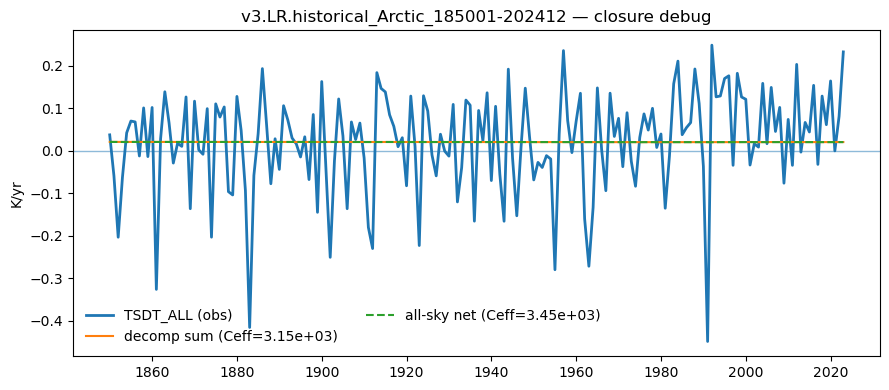

[debug] closure: {'decomp': {'ceff': 3153.7511594285984, 'rmse': 0.11887151371044921, 'r2': -0.0004854681922423776, 'corr': -0.17941320011766912}, 'allsky': {'available': True, 'ceff': 3453.696497887421, 'rmse': 0.11887904314155506, 'r2': -0.0006122155473711199, 'corr': -0.21034028885955017}}


NameError: name 'xxxx' is not defined

In [21]:
if __name__ == "__main__":
    # --- paths ---
    top_path  = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble"
    out_path  = str(V3LE_DIAG_DIR)
    fig_path  = str(FIG_DIR_ROOT)

    # --- controls ---
    regnam     = "Arctic"                 # label only
    dtype      = "climo"
    period     = "185001-202412"          # must match filenames
    prefix     = "v3.LR.historical"
    tail       = "area_mean_ts"
    join_mode  = "exact"                  # robust if some members end early

    # --- I/O dirs ---
    out_dir = f"{out_path}/{regnam}"
    fig_dir = f"{fig_path}/{regnam}"
    os.makedirs(out_dir, exist_ok=True)
    os.makedirs(fig_dir, exist_ok=True)
    data_path = f"{top_path}/data/{regnam}"

    # --- read ensemble time series (RAW annual means; dims: ens,time) ---
    reader = ExpDataReader(
        anom_type=None,           # <- no anomalies
        data_dir=data_path,
        regnam=regnam,
        dtype=dtype,
        verbose=True,
    )
    _ = reader._normalize_period_str(period)

    # Expect the file(s) to contain annual-mean RAW variables:
    # TS, FSDSC, (ALBEDOC_SRF or FSNSC), (FLDSC or FLDS), SHFLX, LHFLX, [optional SWCF_SRF, LWCF_SRF]
    ens = reader.read_ensemble_ts(
        prefix=prefix,
        tail=tail,
        period=period,
        join=join_mode,
        validate_annual=True,
    )

    # --- build raw-only budget ---
    bud = EnsembleTSBudgetRaw(ens, name=f"{prefix}_{regnam}_{period}")

    # 1) Estimate C_eff from RAW series (ensemble means for stability)
    ceff = bud.estimate_ceff()
    print(f"[info] C_eff = {ceff:.3e} J m^-2 K^-1")

    # 2) Compute per-member tendency contributions (K/yr), left-indexed y→y+1
    ds = bud.compute(ceff=ceff)

    # 3) Save outputs
    nc_path = os.path.join(out_dir, f"ts_budget_raw_tendency_{prefix}_{regnam}_{period}.nc")
    ds.to_netcdf(nc_path)
    print(f"[write] {nc_path}")

    # 4) Stats table (ensemble mean & 5–95% band) for key terms
    terms = [t for t in ["TSDT_ALL","TSDT_Sum","TSDT_SWclr","TSDT_LWclr",
                         "TSDT_Planck","TSDT_CRE","TSDT_SH","TSDT_LH","TSDT_RESID"] if t in ds]
    stats_df = bud.compute_stats(ds, terms=terms)
    csv_path = os.path.join(out_dir, f"ts_budget_raw_tendency_stats_{prefix}_{regnam}_{period}.csv")
    stats_df.to_csv(csv_path, index=False)
    print(f"[write] {csv_path}")
    
    # 6) Closure diagnostics (prints fitted Ceffs & metrics; writes optional plot)
    diag_png = os.path.join(fig_dir, f"TS_budget_closure_debug_{prefix}_{period}.png")
    diag = bud.debug_closure(make_plot=True, outpath=diag_png, show=True)
    print("[debug] closure:", diag)
    print(xxxx)
    
    # 5) One-panel comparison plot
    pdf_path = os.path.join(fig_dir, f"TS_budget_all_terms_{prefix}_{period}.pdf")
    bud.plot_all_terms_one_panel(
        ds,
        terms=terms,  # reuse the list you built for the stats
        title=f"{prefix} • {regnam} • TS budget contributions (K/yr)",
        outpath=pdf_path,
        show=True,
    )
    print("[done] RAW TS budget completed.")
